In [1]:
from astropy import constants as const
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt

def grid_R(NR, dR):
    R = np.zeros(NR)
    l = 10 / dR
    for i in range(NR):
        if i * dR < 10:
            R[i] = i * dR
        else:
            R[i] = 10** ((i + l ) / 2 / l)
    return R
def grid_Z(NZ, dZ):
    Z = np.zeros(NZ)
    l = 1 / dZ
    for i in range(NZ):
        if i * dZ < 1:
            Z[i] = i * dZ
        else:
            Z[i] = 10** ((i - l) / l)
    return Z

In [2]:
ls

CN_ADI.ipynb                            diffusion_func.h
Makefile                                main.c
diff_adv_func.c                         main_adv.c
diff_adv_func.h                         main_adv.o
diff_adv_func.o                         ndis_B11_10GV_R200_Z251_H001_t1e10.bin
diff_adv_sim*                           ndis_C12_10GV_R200_Z251_H001_t1e10.bin
diffusion_func.c


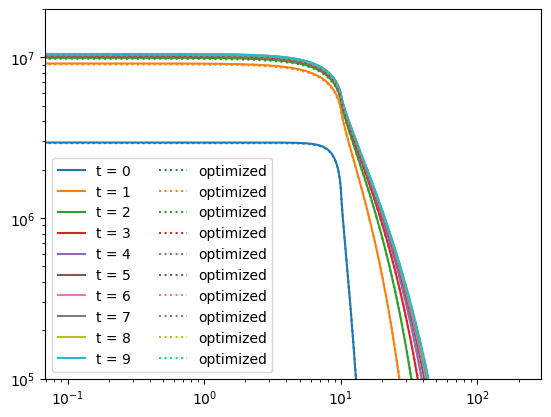

In [14]:
NR = 361
NZ = 171
R = grid_R(NR,0.1)
Z = grid_Z(NZ,0.02)
ndis_C = np.fromfile("ndis_C12_10GV_R200_Z251_H001_t1e10.bin",dtype=np.float64).reshape(200, NR, NZ)
ndis_B = np.fromfile("ndis_B11_10GV_R200_Z251_H001_t1e10.bin",dtype=np.float64).reshape(200, NR, NZ)
ndis_C1 = np.fromfile("ndis_C12_10GV_R200_Z251_H001_t1e10_opt.bin",dtype=np.float64).reshape(200, NR, NZ)
ndis_B1 = np.fromfile("ndis_B11_10GV_R200_Z251_H001_t1e10_opt.bin",dtype=np.float64).reshape(200, NR, NZ)
ndis_C2 = np.fromfile("ndis_C12_10GV_R200_Z251_H001_t1e10_opt1.bin",dtype=np.float64).reshape(200, NR, NZ)
ndis_B2 = np.fromfile("ndis_B11_10GV_R200_Z251_H001_t1e10_opt1.bin",dtype=np.float64).reshape(200, NR, NZ)
for i in range(10):
    plt.plot(R, ndis_C[i*20,:,0], label = f"t = {i}")
for i in range(10):
    plt.plot(R, ndis_C2[i*20,:,0], label = f"optimized", linestyle="dotted")

plt.xscale("log")
plt.yscale("log")
plt.ylim(1e5,2e7)
plt.legend(ncol=2)

In [15]:
ind = 20
ratio = (ndis_C[:,:-ind,:-ind] - ndis_C2[:,:-ind,:-ind]) / ndis_C[:,:-ind,:-ind]
np.max(ratio)

np.float64(0.014466339680464704)

In [10]:
np.where(np.isnan(ndis_C1))

(array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))